In [1]:
import matplotlib.pyplot as plt
import numpy as np

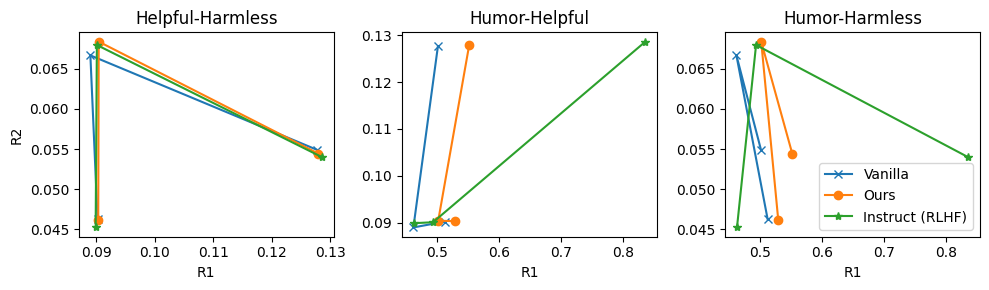

In [2]:
fig, axs = plt.subplots(1,3, figsize=(10,3))


axs[0].plot([0.09022965077125836, 0.08900000622419983, 0.12763357957276544],
            [0.046223781696034257, 0.06667464295167064, 0.054918913158581474,],
            label="Vanilla", marker='x')

axs[0].plot([0.0903425223031852, 0.09042233758733659, 0.12794605746958335],
            [0.04611676592097185, 0.06838835253135657, 0.054421833780875596,],
            label="Ours", marker='o')

axs[0].plot([0.08990252414331527, 0.0901084019659847, 0.1286185756372409],
            [0.04522162526042432, 0.06796770398364232, 0.05396462384333969,],
            label="Instruct (RLHF)", marker="*")

# axs[0].set_yscale("log")
axs[0].set_title("Helpful-Harmless")
axs[0].set_ylabel("R2")
axs[0].set_xlabel("R1")
# axs[0].legend()


axs[1].plot([0.5123908072828179, 0.46197533579827066,  0.5015259995507637],[0.09022965077125836, 0.08900000622419983, 0.12763357957276544,],
            
            label="Vanilla", marker='x')

axs[1].plot([0.5294942558790633,  0.5019776343193082,  0.5520543201557353],[0.0903425223031852, 0.09042233758733659, 0.12794605746958335,],
            
            label="Ours", marker='o')

axs[1].plot([0.4628930583871334, 0.4936649588408203, 0.8361682015573522],[0.08990252414331527, 0.0901084019659847, 0.1286185756372409,],
            
            label="Instruct (RLHF)", marker="*")
# axs[1].set_yscale("log")
axs[1].set_title("Humor-Helpful")
# axs[1].set_ylabel("R2")
axs[1].set_xlabel("R1")
# axs[1].legend()


axs[2].plot([0.5123908072828179,  0.46197533579827066, 0.5015259995507637], [0.046223781696034257,  0.06667464295167064, 0.054918913158581474],
           
            label="Vanilla", marker='x')

axs[2].plot([0.5294942558790633, 0.5019776343193082, 0.5520543201557353],[0.04611676592097185,  0.06838835253135657, 0.054421833780875596],
            
            label="Ours", marker='o')

axs[2].plot([0.4628930583871334, 0.4936649588408203, 0.8361682015573522],[0.04522162526042432, 0.06796770398364232, 0.05396462384333969, ],
            label="Instruct (RLHF)", marker="*")

axs[2].set_title("Humor-Harmless")
# axs[2].set_ylabel("R2")
axs[2].set_xlabel("R1")
axs[2].legend()
plt.tight_layout()
plt.savefig("single_objective.png")
plt.show()

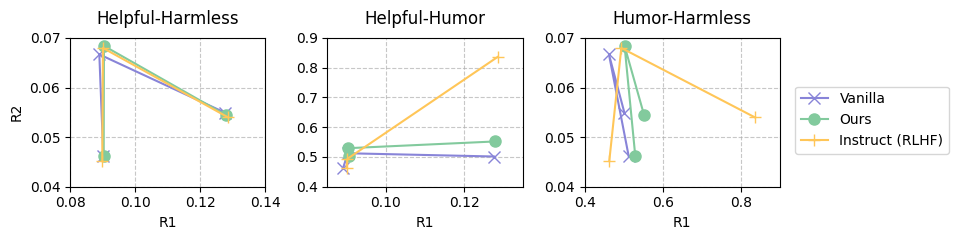

In [16]:
# Data
helpful_harmless = {
    'Vanilla': {'R1': [0.09022965077125836, 0.08900000622419983, 0.12763357957276544], 'R2': [0.046223781696034257, 0.06667464295167064, 0.054918913158581474]},
    'Ours': {'R1': [0.0903425223031852, 0.09042233758733659, 0.12794605746958335], 'R2': [0.04611676592097185, 0.06838835253135657, 0.054421833780875596]},
    'Instruct': {'R1': [0.08990252414331527, 0.0901084019659847, 0.1286185756372409], 'R2': [0.04522162526042432, 0.06796770398364232, 0.05396462384333969]}
}

humor_helpful = {
    'Vanilla': {'R1': [0.08900000622419983, 0.09022965077125836, 0.12763357957276544,], 'R2':[0.46197533579827066, 0.5123908072828179, 0.5015259995507637], },
    'Ours': {'R1': [0.09042233758733659, 0.0903425223031852, 0.12794605746958335,],'R2':[0.5019776343193082, 0.5294942558790633,  0.5520543201557353],  },
    'Instruct': {'R1': [0.08990252414331527, 0.0901084019659847, 0.1286185756372409,], 'R2':[0.4628930583871334, 0.4936649588408203, 0.8361682015573522], }
}

humor_harmless = {
    'Vanilla': {'R1': [0.5123908072828179,  0.46197533579827066, 0.5015259995507637], 'R2': [0.046223781696034257,  0.06667464295167064, 0.054918913158581474],},
    'Ours': {'R1': [0.5294942558790633, 0.5019776343193082, 0.5520543201557353], 'R2': [0.04611676592097185,  0.06838835253135657, 0.054421833780875596],},
    'Instruct': {'R1': [0.4628930583871334, 0.4936649588408203, 0.8361682015573522], 'R2': [0.04522162526042432, 0.06796770398364232, 0.05396462384333969, ]}
}

def create_plot(data, title, ax, xlim, ylim):
    styles = {
        'Vanilla': {'color': '#8884d8', 'marker': 'x', 'label': 'Vanilla'},
        'Ours': {'color': '#82ca9d', 'marker': 'o', 'label': 'Ours'},
        'Instruct': {'color': '#ffc658', 'marker': '+', 'label': 'Instruct (RLHF)'}
    }
    for model, style in styles.items():
        ax.plot(data[model]['R1'], data[model]['R2'], 
                color=style['color'],
                marker=style['marker'],
                label=style['label'],
                linestyle='-',
                markersize=8)
    
    ax.set_title(title, pad=10)
    ax.set_xlabel('R1')
    if title == 'Helpful-Harmless':
        ax.set_ylabel('R2')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, linestyle='--', alpha=0.7)
    
# Create figure with subplots
# plt.style.use('seaborn')
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 2.5))
# fig.suptitle('Model Performance Comparison', y=1.05)

# Create individual plots
create_plot(helpful_harmless, 'Helpful-Harmless', ax1, (0.08, 0.14), (0.04, 0.07))
create_plot(humor_helpful, 'Helpful-Humor', ax2, (0.085, 0.135), (0.4, 0.9))
create_plot(humor_harmless, 'Humor-Harmless', ax3, (0.4, 0.9), (0.04, 0.07))

# Add single legend for all subplots
handles, labels = ax1.get_legend_handles_labels()
# fig.legend(handles, labels, loc='center right', bbox_to_anchor=(0.98, 0.5))
fig.legend(handles, labels, 
          loc='center left', 
          bbox_to_anchor=(1.0, 0.5),  # Moved legend outside
          borderaxespad=0)


# Adjust layout
plt.tight_layout()

# Save the plot
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
# plt.close()